# Prefix-Based Leave-One-Out Attribution

This notebook extends the Leave-One-Out analysis by evaluating token importance across successive prefixes of the original prompt.

## Notation and mathematical setup

Let the tokenized prompt be

$$
x_{1:T} = (x_1, x_2, \dots, x_T),
$$

and let $y$ be a fixed target token, here `" Paris"`.

For each prefix length $t \in \{1,\dots,T\}$, we consider the prefix $x_{1:t}$. The main quantity of interest is

$$
v_t = \log p_\theta(y \mid x_{1:t}),
$$

the log-probability assigned by the model to the target after reading that prefix.

To measure token importance within each prefix, we use a leave-one-out (LOO) perturbation. If token $x_i$ is removed from prefix $x_{1:t}$, we denote the perturbed prefix by $x_{1:t}^{(-i)}$. The corresponding LOO score is

$$
\Delta_{i,t}
=
\log p_\theta(y \mid x_{1:t})
-
\log p_\theta(y \mid x_{1:t}^{(-i)}).
$$

A positive value means that removing token $x_i$ decreases the target log-probability, so that token provides positive evidence for $y$ at prefix $t$.

Finally, we summarize each token’s contribution by averaging its LOO scores across the prefixes where it is present:

$$
\bar{\Delta}_i = \frac{1}{N_i} \sum_{t:\, i \le t} \Delta_{i,t},
$$

where $N_i$ is the number of valid prefixes containing token $x_i$.

Since this aggregation is performed in log space, exponentiating the result gives a geometric-average multiplicative effect on the target probability:

$$
\exp(\bar{\Delta}_i)
=
\left(\prod_{t:\, i \le t} \exp(\Delta_{i,t})\right)^{1/N_i}.
$$

## Imports

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

## Load model and tokenizer

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print("Device:", device)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Device: cpu


## Prompt and target

In [3]:
prompt = "The capital of France is"
target = " Paris"

target_display = target.strip()

## Inspect *tokenization*

Before computing target probabilities, it is important to inspect how both the prompt and the target are tokenized. In this example, the target `" Paris"` is a single token, which allows us to track its probability directly. In general, this step matters because multi-token targets would require a different treatment.

In [4]:
prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
target_ids = tokenizer(target, add_special_tokens=False)["input_ids"]

prompt_tokens = tokenizer.convert_ids_to_tokens(prompt_ids)
target_tokens = tokenizer.convert_ids_to_tokens(target_ids)

decoded_prompt_tokens = [tokenizer.decode([tid]).strip() for tid in prompt_ids]
decoded_target_tokens = [tokenizer.decode([tid]).strip() for tid in target_ids]

print("Prompt ids:", prompt_ids)
print("Prompt tokens:", prompt_tokens)
print("Target ids:", target_ids)
print("Target tokens:", target_tokens)
print("Decoded prompt tokens:", decoded_prompt_tokens)
print("Decoded target tokens:", decoded_target_tokens)

Prompt ids: [785, 6722, 315, 9625, 374]
Prompt tokens: ['The', 'Ġcapital', 'Ġof', 'ĠFrance', 'Ġis']
Target ids: [12095]
Target tokens: ['ĠParis']
Decoded prompt tokens: ['The', 'capital', 'of', 'France', 'is']
Decoded target tokens: ['Paris']


In [5]:
target_id = target_ids[0]

##  Definition of value functions for target log-probability

We now implement the quantities introduced above. The first helper function extracts the target log-probability for all prefixes from a single forward pass over the full prompt. The second recomputes the target log-probability for a modified input, which is needed for the leave-one-out analysis.

In [6]:
def get_prefix_target_logprobs(prompt_ids, target_id, model, device):
    input_tensor = torch.tensor([prompt_ids], device=device)

    model_inputs = {
        "input_ids": input_tensor,
        "attention_mask": torch.ones_like(input_tensor)
    }

    with torch.no_grad():
        outputs = model(**model_inputs)

    all_logprobs = F.log_softmax(outputs.logits[0].float(), dim=-1)
    target_logprobs = all_logprobs[:, target_id]

    return target_logprobs.float().cpu().numpy()


In [7]:
def get_target_logprob(input_ids, target_id, model, device):
    input_tensor = torch.tensor([input_ids], device=device)

    model_inputs = {
        "input_ids": input_tensor,
        "attention_mask": torch.ones_like(input_tensor)
    }

    with torch.no_grad():
        outputs = model(**model_inputs)

    next_token_logits = outputs.logits[0, -1, :]
    next_token_logprobs = F.log_softmax(next_token_logits, dim=-1)

    return next_token_logprobs[target_id].item()

## Log-probability of the target across prefixes

We first compute $v_t = \log p_\theta(y \mid x_{1:t})$ for every prefix of the prompt. This shows how the model’s evidence for the target changes as the context grows. Since the full prompt is processed in one forward pass, all prefix scores can be extracted efficiently from the same computation.

In [8]:
prefix_logprobs = get_prefix_target_logprobs(
    prompt_ids, target_id, model, device
)

prefix_texts = [
    tokenizer.decode(prompt_ids[:t])
    for t in range(1, len(prompt_ids) + 1)
]

In [9]:
import pandas as pd

prefix_probs = np.exp(prefix_logprobs)

df_prefix = pd.DataFrame({
    "prefix_index": range(1, len(prefix_texts) + 1),
    "prefix_text": prefix_texts,
    "prob_target": prefix_probs,
    "logprob_target": prefix_logprobs
})

df_prefix

,prefix_index,prefix_text,prob_target,logprob_target
0,1,The,0.000021,-10.794415
1,2,The capital,0.000062,-9.692124
2,3,The capital of,0.000177,-8.639520
3,4,The capital of France,0.004499,-5.403835
4,5,The capital of France is,0.314744,-1.155994


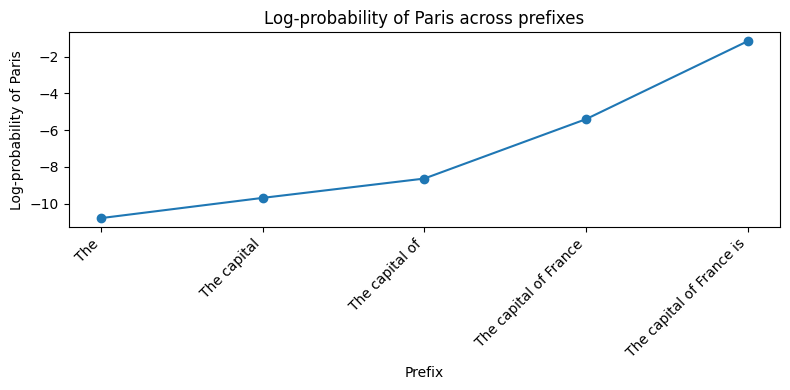

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(df_prefix["prefix_index"], df_prefix["logprob_target"], marker="o")
plt.xticks(df_prefix["prefix_index"], df_prefix["prefix_text"], rotation=45, ha="right")
plt.xlabel("Prefix")
plt.ylabel(f"Log-probability of {target_display}")
plt.title(f"Log-probability of {target_display} across prefixes")
plt.tight_layout()
plt.show()

In [ ]:
# import os
# os.makedirs("figures", exist_ok=True)

# plt.figure(figsize=(8, 4))
# plt.plot(df_prefix["prefix_index"], df_prefix["logprob_target"], marker="o")
# plt.xticks(df_prefix["prefix_index"], df_prefix["prefix_text"], rotation=45, ha="right")
# plt.xlabel("Prefix")
# plt.ylabel(f"Log-probability of {target_display}")
# plt.title(f"Log-probability of {target_display} across prefixes")
# plt.tight_layout()

# plt.savefig("figures/prefix_logprob_curve.png", dpi=300, bbox_inches="tight")

# plt.show()

## Prefix-based leave-one-out

We now extend the analysis with a prefix-based leave-one-out procedure. For each prefix, we remove one token at a time and recompute the log-probability of the target. The difference between the original and perturbed values is the LOO score $\Delta_{i,t}$, which measures how much that token supports the target within that prefix.

In [11]:
T = len(prompt_ids)

loo_matrix = np.full((T, T), np.nan)

base_logprobs = prefix_logprobs

for t in range(1, T + 1):
    
    prefix_ids = prompt_ids[:t]
    base_lp = base_logprobs[t - 1]

    for i in range(t):
        loo_ids = prefix_ids[:i] + prefix_ids[i+1:]

        if len(loo_ids) == 0:
            continue

        loo_lp = get_target_logprob(loo_ids, target_id, model, device)

        loo_matrix[i, t - 1] = base_lp - loo_lp

## Visualizing the prefix-based LOO matrix

The resulting matrix summarizes token importance across prefixes. Rows correspond to removed tokens and columns correspond to evaluated prefixes. Each cell shows the drop in target log-probability after removing one token from one prefix. This makes it possible to see not only which tokens matter, but also when they start to matter as the prompt is built.

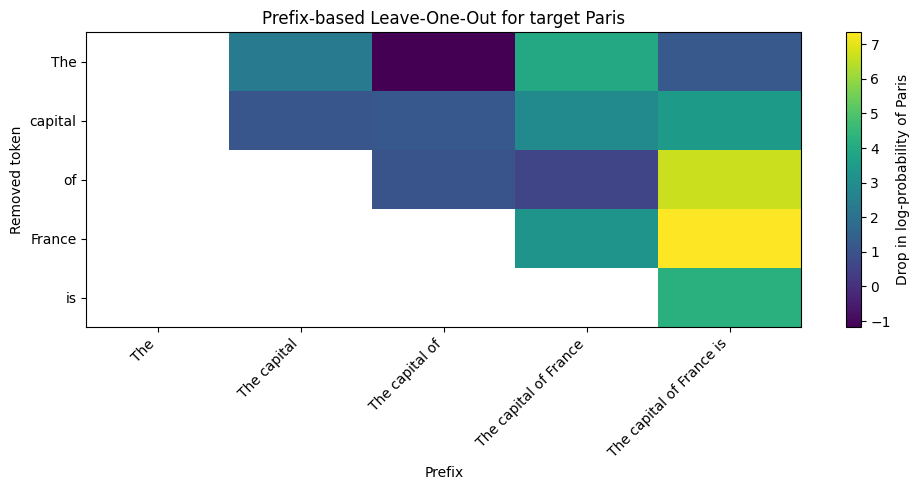

In [12]:
row_labels = [tok.replace("Ġ", " ") for tok in prompt_tokens]
col_labels = [tokenizer.decode(prompt_ids[:t]) for t in range(1, T + 1)]

plt.figure(figsize=(10, 5))
plt.imshow(loo_matrix, aspect="auto")

plt.colorbar(label=f"Drop in logprob of {target_display}")

plt.xticks(range(T), col_labels, rotation=45, ha="right")
plt.yticks(range(T), row_labels)

plt.xlabel("Prefix")
plt.ylabel("Removed token")
plt.title(f"Prefix-based LOO for target {target_display}")

plt.tight_layout()
plt.show()

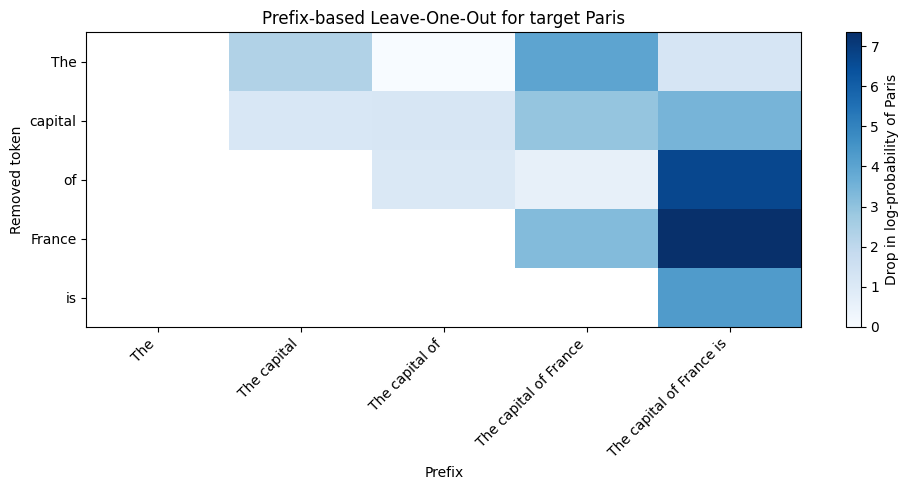

In [ ]:
# os.makedirs("figures", exist_ok=True)

# row_labels = [tok.replace("Ġ", "").strip() for tok in prompt_tokens]
# col_labels = [tokenizer.decode(prompt_ids[:t]).strip() for t in range(1, T + 1)]

# masked_matrix = np.ma.masked_invalid(loo_matrix)

# cmap = mpl.cm.Blues.copy()
# cmap.set_bad(color="white")

# vmax = np.nanmax(loo_matrix)

# plt.figure(figsize=(10, 5))
# plt.imshow(
#     masked_matrix,
#     aspect="auto",
#     cmap=cmap,
#     vmin=0,
#     vmax=vmax
# )

# plt.colorbar(label=f"Drop in log-probability of {target_display}")

# plt.xticks(range(T), col_labels, rotation=45, ha="right")
# plt.yticks(range(T), row_labels)

# plt.xlabel("Prefix")
# plt.ylabel("Removed token")
# plt.title(f"Prefix-based Leave-One-Out for target {target_display}")

# plt.tight_layout()

# plt.savefig("figures/prefix_loo_heatmap.png", dpi=300, bbox_inches="tight")
# plt.show()

## Mean token contribution across prefixes

Finally, we summarize the importance of each token by averaging its LOO log-probability drops across all valid prefixes with `np.nanmean`. This avoids penalizing tokens that appear later in the prompt and are therefore present in fewer prefixes. Exponentiating the average gives a multiplicative interpretation of the effect: values above 1 mean that the token tends to increase the probability of the target across prefixes, while values below 1 mean the opposite.

In [13]:
mean_importance = np.nanmean(loo_matrix, axis=1)
importance_ratio = np.exp(mean_importance)

df_importance = pd.DataFrame({
    "token": row_labels,
    "mean_logprob_drop": mean_importance,
    "geometric_probability_ratio": importance_ratio
})

df_importance = df_importance.sort_values(
    "mean_logprob_drop", ascending=False
).reset_index(drop=True)

df_importance

,token,mean_logprob_drop,geometric_probability_ratio
0,France,5.282585,196.878223
1,is,4.250256,70.123333
2,of,2.766884,15.908979
3,capital,2.167757,8.738658
4,The,1.581819,4.863796


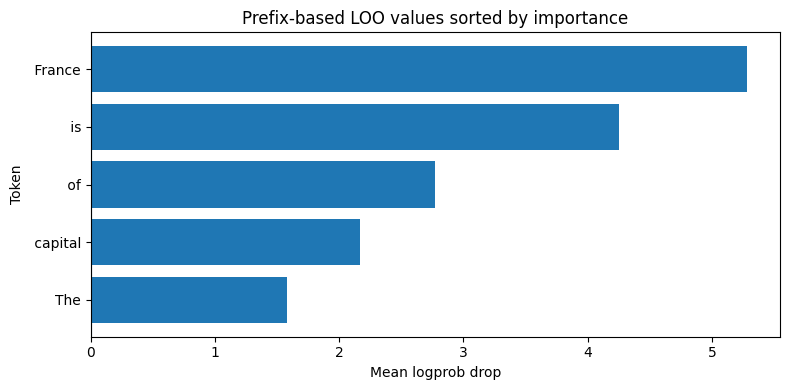

In [14]:
order = np.argsort(np.abs(mean_importance))[::-1]
tokens_sorted = [row_labels[i] for i in order]
values_sorted = mean_importance[order]

plt.figure(figsize=(8, 4))
plt.barh(tokens_sorted, values_sorted)
plt.axvline(0)

plt.xlabel("Mean logprob drop")
plt.ylabel("Token")
plt.title("Prefix-based LOO values sorted by importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()